In [1]:
# ===== Core =====
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# ===== Visualization =====
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno
# ===== Statistics & Tests (optional) =====
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind, randint, uniform, loguniform
import statsmodels.api as sm
from patsy import dmatrix
import seaborn as sns

# ===== Scikit-learn Core =====
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder


# ===== Regression Models =====
# Linear
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor, TweedieRegressor
)

# Neighbors / SVM
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Trees & Ensembles
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA

# Baseline
from sklearn.dummy import DummyRegressor

# ===== Gradient Boosting Libraries =====
have_xgb = have_lgbm = have_cat = False

try:
    from xgboost import XGBRegressor
    have_xgb = True
except Exception:
    pass

try:
    from lightgbm import LGBMRegressor
    have_lgbm = True
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    have_cat = True
except Exception:
    pass

warnings.filterwarnings("ignore")


# **Data Loading**

In [2]:
#loading data
df_raw = pd.read_csv("../data/insurance.csv")
df = df_raw.copy()

# seperate for modeling later
df_model = df_raw.copy()

# **Data Cleaning**

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: >

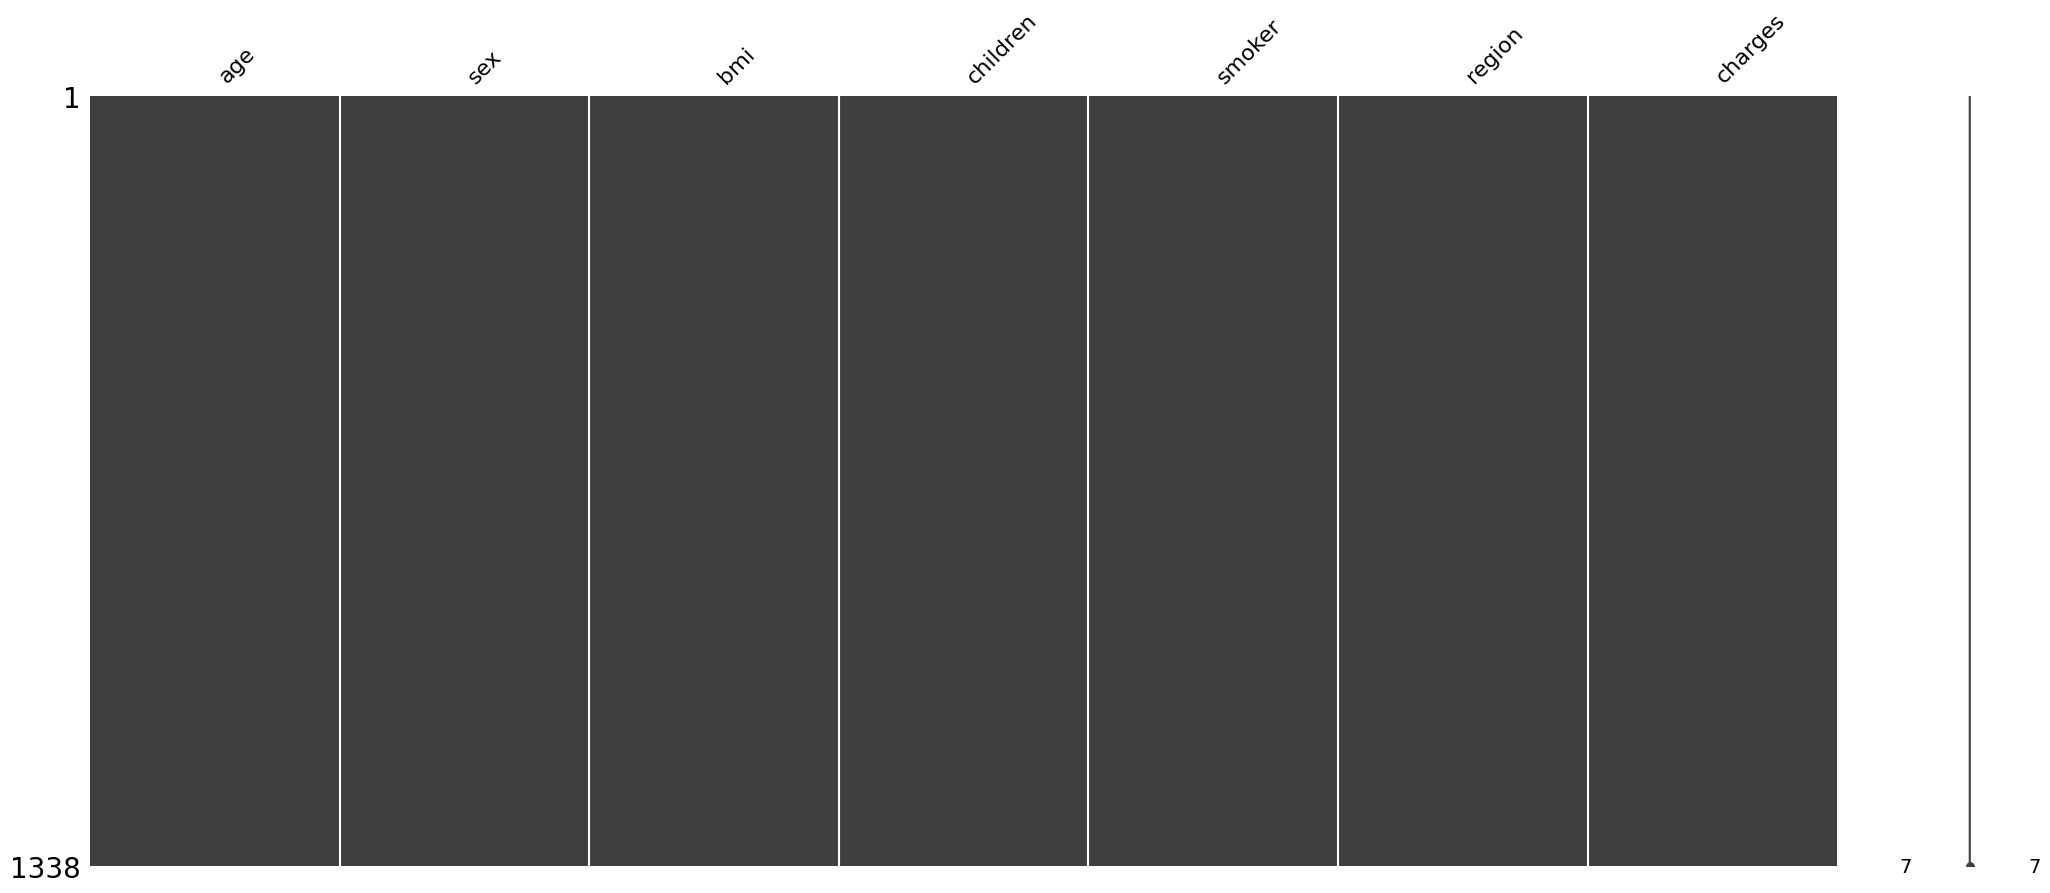

In [6]:
msno.matrix(df)

In [7]:
df.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
for col in ["sex", "smoker"]:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print("Unique:", df[col].unique())
        print("\nValue counts:")
        print(df[col].value_counts(dropna=False))




=== sex ===
Unique: ['female' 'male']

Value counts:
sex
male      676
female    662
Name: count, dtype: int64

=== smoker ===
Unique: ['yes' 'no']

Value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64


# **EDA**

<Axes: xlabel='charges', ylabel='Count'>

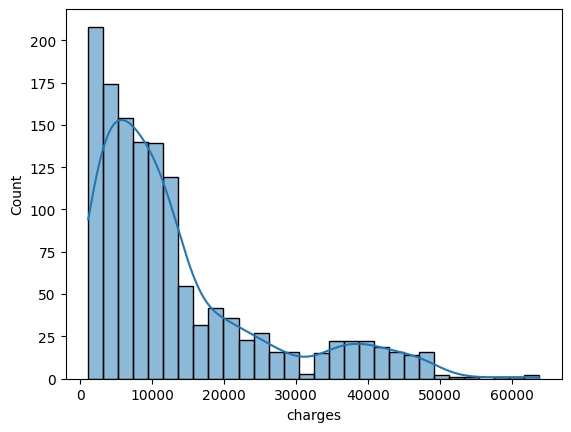

In [9]:
sns.histplot(data=df,x='charges',kde=True)

<Axes: xlabel='charges', ylabel='Count'>

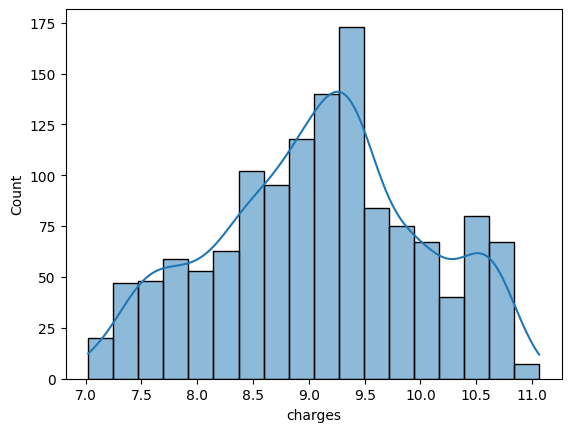

In [10]:
sns.histplot(x=np.log(df['charges']), kde=True)

In [11]:
df["smoker_raw"] = df["smoker"]
df["sex_raw"]    = df["sex"]

def to01_yesno(s):
    s = s.astype(str).str.strip().str.lower()
    return s.map({"yes":1,"y":1,"true":1,"1":1, "no":0,"n":0,"false":0,"0":0})

def to01_malefemale(s):
    s = s.astype(str).str.strip().str.lower()
    return s.map({"male":1,"m":1, "female":0,"f":0})

# Create numeric columns for correlation heatmap without overwriting string originals
df["smoker_bin"] = to01_yesno(df["smoker"]).astype("Int64")
df["sex_bin"]    = to01_malefemale(df["sex"]).astype("Int64")

print("Unmapped smoker:", df.loc[df["smoker_bin"].isna(), "smoker_raw"].unique())
print("Unmapped sex:",    df.loc[df["sex_bin"].isna(),    "sex_raw"].unique())

Unmapped smoker: []
Unmapped sex: []


<Axes: >

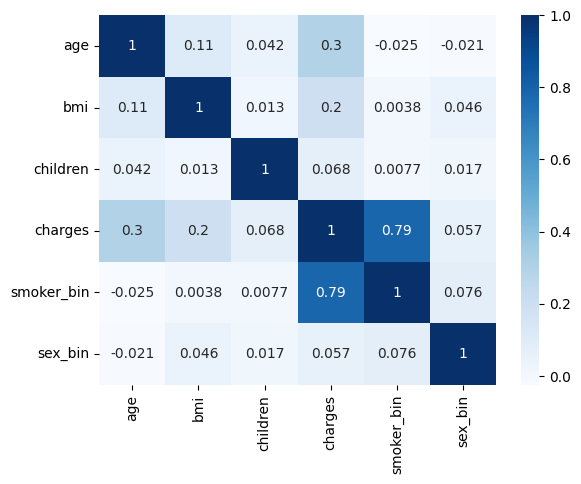

In [12]:
df["smoker_raw"] = df["smoker_raw"]
df["sex_raw"]    = df["sex_raw"]
num_df = df.select_dtypes(include="number")
sns.heatmap(num_df.corr(), annot=True, cmap="Blues")

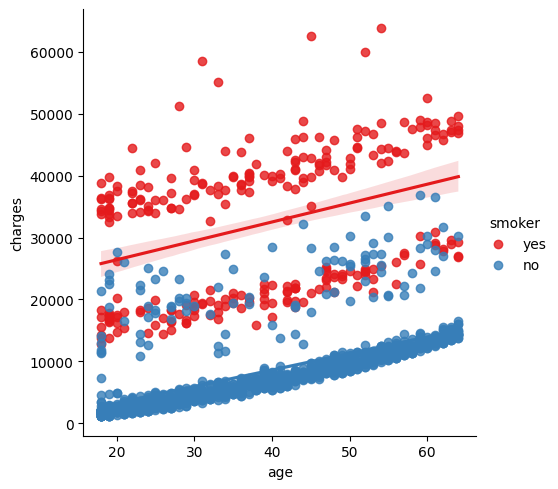

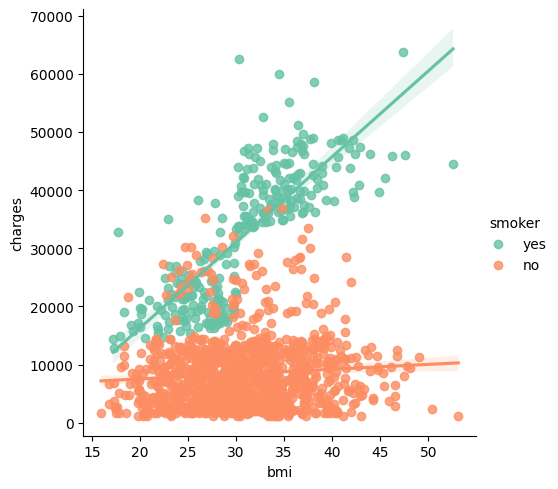

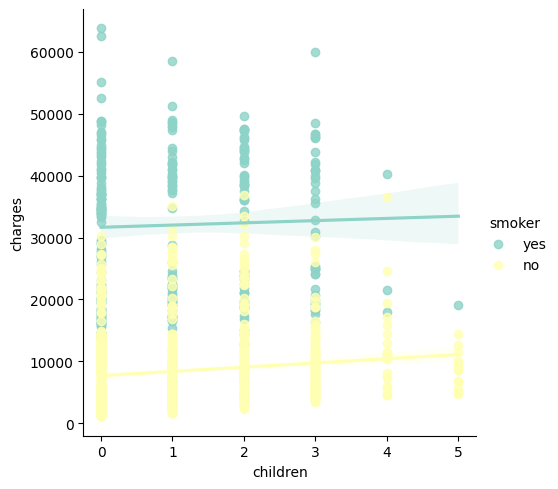

In [13]:
sns.lmplot(x = 'age', y = 'charges', data=df, hue='smoker', palette='Set1')
sns.lmplot(x = 'bmi', y = 'charges', data=df, hue='smoker', palette='Set2')
sns.lmplot(x = 'children', y = 'charges', data=df, hue='smoker', palette='Set3')

In [14]:
avg_by_smoker = df.groupby('smoker')['charges'].mean()
avg_by_smoker

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

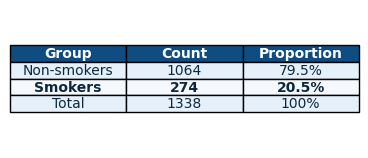

In [15]:
counts = df["smoker"].value_counts()
total = len(df)

table_df = pd.DataFrame({
    "Group": ["Non-smokers", "Smokers", "Total"],
    "Count": [counts["no"], counts["yes"], total],
    "Proportion": [
        f"{counts['no'] / total * 100:.1f}%",
        f"{counts['yes'] / total * 100:.1f}%",
        "100%"
    ]
})

fig, ax = plt.subplots(figsize=(4.5, 1.8))
ax.axis("off")

header_color = "#0F4C81"
row_color_1 = "#E6F0FA"
row_color_2 = "#F5F8FC"
text_color = "#0B2840"

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor(row_color_1 if row % 2 == 1 else row_color_2)
        cell.set_text_props(color=text_color, weight="bold" if row == 2 else None)

plt.show()

## **Age Group**

In [16]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# --- 0) Prepare data ---
age = pd.to_numeric(df["age"], errors="coerce").dropna()
lo, hi = float(age.min()), float(age.max())
mean_age, med_age = float(age.mean()), float(age.median())
std_age, skew_age = float(age.std(ddof=1)), float(age.skew())
n = int(age.size)

# Optional business-range flags (edit if you like)
lower_ok, upper_ok = 18, 90
n_low = int((age < lower_ok).sum())
n_high = int((age > upper_ok).sum())

# --- 1) Histogram (with mean/median reference) ---
hist = go.Histogram(
    x=age,
    nbinsx=30,
    name="Age",
    opacity=0.85,
    marker=dict(line=dict(width=0.5)),
    hovertemplate="Age=%{x}<br>Count=%{y}<extra></extra>"
)

line_mean = go.Scatter(
    x=[mean_age, mean_age], y=[0, max(1, np.histogram(age, bins=30)[0].max())],
    mode="lines", name=f"Mean = {mean_age:.1f}",
    line=dict(dash="dash")
)
line_median = go.Scatter(
    x=[med_age, med_age], y=[0, max(1, np.histogram(age, bins=30)[0].max())],
    mode="lines", name=f"Median = {med_age:.1f}",
    line=dict(dash="dot")
)

fig1 = go.Figure([hist, line_mean, line_median])
fig1.update_layout(
    title="Age Distribution (Histogram)",
    xaxis_title="Age",
    yaxis_title="Count",
    template="plotly_white",
    bargap=0.03,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig1.show()
# fig1.write_html("age_histogram.html")

# --- 2) Boxplot (spot outliers quickly) ---
fig2 = go.Figure(go.Box(
    y=age,
    name="Age",
    boxpoints="outliers",
    hovertemplate="Age=%{y}<extra></extra>"
))
fig2.update_layout(
    title="Age Boxplot",
    yaxis_title="Age",
    template="plotly_white",
    height=420
)
fig2.show()
# fig2.write_html("age_boxplot.html")

# --- 3) Summary table (slide-friendly) ---
summary_df = pd.DataFrame({
    "metric": ["n","min","max","mean","median","std","skew","flag(<18)","flag(>90)"],
    "value":  [n,   f"{lo:.1f}", f"{hi:.1f}", f"{mean_age:.1f}", f"{med_age:.1f}",
               f"{std_age:.1f}", f"{skew_age:.2f}", n_low, n_high]
})

fig3 = go.Figure(data=[go.Table(
    header=dict(values=list(summary_df.columns), fill_color="#f2f2f2", align="left"),
    cells=dict(values=[summary_df["metric"], summary_df["value"]], align="left")
)])
fig3.update_layout(title="Age — Summary Statistics", template="plotly_white")
fig3.show()
# fig3.write_html("age_summary_table.html")


In [17]:
x = pd.to_numeric(df["age"], errors="coerce")
y = pd.to_numeric(df["charges"], errors="coerce")
mask = x.notna() & y.notna()
x, y = x[mask], y[mask]

def binned_means(x, y, q=12):
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(tmp) < 10:
        return pd.DataFrame(columns=["x_mid", "y_mean"])
    tmp["bin"] = pd.qcut(tmp["x"], q=q, duplicates="drop")
    g = tmp.groupby("bin").agg(x_mid=("x","mean"), y_mean=("y","mean")).reset_index(drop=True)
    return g

bm_raw = binned_means(x, y, q=12)

# 1) Scatter: charge ~ age (+ binned-mean trend)
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=x, y=y, mode="markers",
                          name="observations", opacity=0.45,
                          marker=dict(size=5)))
if not bm_raw.empty:
    fig1.add_trace(go.Scatter(x=bm_raw["x_mid"], y=bm_raw["y_mean"],
                              mode="lines+markers",
                              name="binned mean (12-quantiles)"))
fig1.update_layout(title="Charge vs Age (with binned-mean trend)",
                   xaxis_title="age", yaxis_title="charge",
                   template="plotly_white", height=520)
fig1.show()
# fig1.write_html("fig1_charge_vs_age.html")

# 2) Scatter: log(charge) ~ age (+ binned-mean trend)
pos = y > 0
x_log = x[pos]
y_log = np.log(y[pos])                # use np.log1p if you prefer log(1+charge)
bm_log = binned_means(x_log, y_log, q=12)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=x_log, y=y_log, mode="markers",
                          name="observations (log)", opacity=0.45,
                          marker=dict(size=5)))
if not bm_log.empty:
    fig2.add_trace(go.Scatter(x=bm_log["x_mid"], y=bm_log["y_mean"],
                              mode="lines+markers",
                              name="binned mean (12-quantiles)"))
fig2.update_layout(title="log(Charge) vs Age (with binned-mean trend)",
                   xaxis_title="age", yaxis_title="log(charge)",
                   template="plotly_white", height=520)
fig2.show()

In [18]:
df['Age_Group'] = np.nan

for i in range(len(df)):
    if df.loc[i, 'age'] >= 18 and df.loc[i, 'age'] <= 29:
        df.loc[i, 'Age_Group'] = 'Young'
    elif df.loc[i, 'age'] > 29 and df.loc[i, 'age'] <= 40:
        df.loc[i, 'Age_Group'] = 'Young Adults'
    elif df.loc[i, 'age'] > 40 and df.loc[i, 'age'] <= 55:
        df.loc[i, 'Age_Group'] = 'Senior'
    elif df.loc[i, 'age'] > 55:
        df.loc[i, 'Age_Group'] = 'Elder'

df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_raw,sex_raw,smoker_bin,sex_bin,Age_Group
0,19,female,27.900,0,yes,southwest,16884.92400,yes,female,1,0,Young
1,18,male,33.770,1,no,southeast,1725.55230,no,male,0,1,Young
2,28,male,33.000,3,no,southeast,4449.46200,no,male,0,1,Young
3,33,male,22.705,0,no,northwest,21984.47061,no,male,0,1,Young Adults
4,32,male,28.880,0,no,northwest,3866.85520,no,male,0,1,Young Adults


In [19]:
young        = df['charges'].loc[df['Age_Group'] == 'Young'].values.tolist()
young_adults = df['charges'].loc[df['Age_Group'] == 'Young Adults'].values.tolist()
senior       = df['charges'].loc[df['Age_Group'] == 'Senior'].values.tolist()
elder_charge = df['charges'].loc[df['Age_Group'] == 'Elder'].values.tolist()

young_credit = go.Box(
    y=young, name="Young", jitter=0.3, pointpos=-1.8, boxpoints='all',
    marker=dict(color='rgb(150, 198, 109)'),
    line=dict(color='rgb(111, 200, 37)')
)
young_adults_credit = go.Box(
    y=young_adults, name="Young Adults", jitter=0.3, pointpos=-1.8, boxpoints='all',
    marker=dict(color='rgb(124, 236, 212)'),
    line=dict(color='rgb(38, 214, 177)')
)
senior_credit = go.Box(
    y=senior, name="Seniors", jitter=0.3, pointpos=-1.8, boxpoints='all',
    marker=dict(color='rgb(241, 93, 93)'),
    line=dict(color='rgb(225, 44, 44)')
)
elder_credit = go.Box(
    y=elder_charge, name="Elders", jitter=0.3, pointpos=-1.8, boxpoints='all',
    marker=dict(color='rgb(180, 121, 72)'),
    line=dict(color='rgb(115, 77, 46)')
)

fig = go.Figure(data=[young_credit, young_adults_credit, senior_credit, elder_credit])
fig.update_layout(
    title="Insurance Charges by Age Group",
    xaxis_title="Age Group",
    yaxis_title="Charges ($)",
    template="plotly_white"
)
fig.show()

In [20]:
df["smoker"] = df["smoker"].astype(str).str.lower().str.strip()

# Create age bins
age_bins = pd.cut(df["age"], bins=[18, 29, 44, 59, 80], right=True)
g = df.groupby(["smoker", age_bins])["charges"].mean().reset_index()

fig1 = go.Figure()
for s in sorted(g["smoker"].unique()):
    sub = g[g["smoker"] == s]
    fig1.add_trace(go.Scatter(
        x=sub["age"].astype(str),
        y=sub["charges"],
        mode="lines+markers",
        name=f"smoker={s}"
    ))
fig1.update_layout(
    title="Interaction: Mean Charge by Age Bin and Smoker",
    xaxis_title="Age bins",
    yaxis_title="Mean charge",
    template="plotly_white"
)
fig1.show()


In [21]:
# --- 0) Prepare df ---
# Expect df has: 'age', 'smoker', and 'charges' (or 'charge')
if "charge" in df.columns and "charges" not in df.columns:
    df = df.rename(columns={"charge": "charges"})

d = df.copy()
d["smoker"]  = d["smoker"].astype(str).str.strip().str.lower()
d["age"]     = pd.to_numeric(d["age"], errors="coerce")
d["charges"] = pd.to_numeric(d["charges"], errors="coerce")
d = d.dropna(subset=["age","smoker","charges"])

# --- 1) Define age bins (edit edges if you like) ---
age_edges = [18, 29, 44, 59, 90]   # -> (18–29], (29–44], (44–59], (59–90]
d["age_bin"] = pd.cut(d["age"], bins=age_edges, right=True, include_lowest=True)

# --- 2) Mean charges by age_bin × smoker ---
means = d.groupby(["age_bin","smoker"])["charges"].mean().unstack("smoker")

# Ensure both columns exist (yes/no)
for col in ["yes","no"]:
    if col not in means.columns:
        means[col] = np.nan

# Keep order and compute metrics
tbl = means[["no","yes"]].copy().rename(columns={"no":"mean_non_smoker","yes":"mean_smoker"})
tbl["gap_abs"]    = tbl["mean_smoker"] - tbl["mean_non_smoker"]
tbl["uplift_pct"] = (tbl["mean_smoker"] / tbl["mean_non_smoker"] - 1.0) * 100.0

# --- 3) Build plotting vectors ---
x_labels    = [str(b) for b in tbl.index]
y_gap       = tbl["gap_abs"].values
uplift_text = [f"{u:.0f}%" if np.isfinite(u) else "" for u in tbl["uplift_pct"].values]

# --- 4) Plotly: Dual-axis overlay ---
fig = go.Figure()

# Bars: absolute gap ($)
fig.add_trace(go.Bar(
    x=x_labels, y=y_gap, name="Gap ($)",
    marker_color="indianred",
    text=uplift_text, textposition="outside"
))

# Line: % uplift (right axis)
fig.add_trace(go.Scatter(
    x=x_labels, y=tbl["uplift_pct"], name="Uplift (%)",
    yaxis="y2", mode="lines+markers",
    line=dict(color="royalblue", width=2)
))

fig.update_layout(
    title="Smoking Cost Penalty by Age Bin – Absolute vs % Uplift",
    xaxis_title="Age bin",
    yaxis=dict(title="Gap in mean charges ($)", side="left"),
    yaxis2=dict(title="% Uplift", overlaying="y", side="right"),
    template="plotly_white",
    height=520,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# (Optional) Save to HTML
# fig.write_html("age_smoker_dual_axis.html")

# (Optional) Peek at the table used for plotting:
# display(tbl.reset_index())


## **BMI**


In [22]:
bmi = pd.to_numeric(df["bmi"], errors="coerce").dropna()
n = int(bmi.size)
lo, hi = float(bmi.min()), float(bmi.max())
mean_bmi, med_bmi = float(bmi.mean()), float(bmi.median())
std_bmi, skew_bmi = float(bmi.std(ddof=1)), float(bmi.skew())

# WHO thresholds
t_under = 18.5
t_normal = 25.0
t_over  = 30.0
t_obese2= 35.0

# --- 1) Histogram (with WHO bands + mean/median lines) ---
# Build histogram first to get a good y-range for lines
counts, edges = np.histogram(bmi, bins=30)
ymax = max(1, counts.max())

bands = [
    # (x0, x1, color, name)
    (0, t_under, "rgba(52,152,219,0.12)", "Underweight <18.5"),
    (t_under, t_normal, "rgba(46,204,113,0.12)", "Normal 18.5–24.9"),
    (t_normal, t_over, "rgba(241,196,15,0.12)", "Overweight 25–29.9"),
    (t_over, 100, "rgba(231,76,60,0.12)", "Obese ≥30")
]

fig1 = go.Figure()

# WHO background bands
for x0, x1, color, name in bands:
    fig1.add_shape(type="rect", x0=x0, x1=x1, y0=0, y1=ymax,
                   fillcolor=color, line=dict(width=0), layer="below")

fig1.add_trace(go.Histogram(
    x=bmi, nbinsx=30, name="BMI",
    opacity=0.9, marker=dict(line=dict(width=0.4)),
    hovertemplate="BMI=%{x:.1f}<br>Count=%{y}<extra></extra>"
))

# Mean & Median lines
fig1.add_trace(go.Scatter(
    x=[mean_bmi, mean_bmi], y=[0, ymax],
    mode="lines", name=f"Mean = {mean_bmi:.1f}",
    line=dict(dash="dash", width=2)
))
fig1.add_trace(go.Scatter(
    x=[med_bmi, med_bmi], y=[0, ymax],
    mode="lines", name=f"Median = {med_bmi:.1f}",
    line=dict(dash="dot", width=2)
))

fig1.update_layout(
    title="BMI Distribution (Histogram with WHO Bands)",
    xaxis_title="BMI", yaxis_title="Count",
    template="plotly_white",
    bargap=0.03,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    height=520
)
fig1.show()
# fig1.write_html("bmi_histogram.html")

# --- 2) Boxplot (spot outliers quickly) ---
fig2 = go.Figure(go.Box(
    y=bmi, name="BMI",
    boxpoints="outliers", boxmean="sd",
    hovertemplate="BMI=%{y:.1f}<extra></extra>"
))
fig2.update_layout(
    title="BMI Boxplot",
    yaxis_title="BMI",
    template="plotly_white",
    height=420
)
fig2.show()
# fig2.write_html("bmi_boxplot.html")

# --- 3) Summary table (slide-friendly) ---
summary_df = pd.DataFrame({
    "metric": ["n","min","max","mean","median","std","skew",
               "% <18.5","% 18.5–24.9","% 25–29.9","% ≥30"],
    "value": [
        n, f"{lo:.1f}", f"{hi:.1f}", f"{mean_bmi:.1f}", f"{med_bmi:.1f}",
        f"{std_bmi:.1f}", f"{skew_bmi:.2f}",
        f"{(bmi.lt(t_under).mean()*100):.1f}%",
        f"{(bmi.between(t_under, t_normal, inclusive='left').mean()*100):.1f}%",
        f"{(bmi.between(t_normal, t_over, inclusive='left').mean()*100):.1f}%",
        f"{(bmi.ge(t_over).mean()*100):.1f}%"
    ]
})

fig3 = go.Figure(data=[go.Table(
    header=dict(values=list(summary_df.columns), fill_color="#f2f2f2", align="left"),
    cells=dict(values=[summary_df["metric"], summary_df["value"]], align="left")
)])
fig3.update_layout(title="BMI — Summary Statistics", template="plotly_white")
fig3.show()
# fig3.write_html("bmi_summary_table.html")


In [23]:
# ==== 1) Clean ====
bmi = pd.to_numeric(df["bmi"], errors="coerce")
chg = pd.to_numeric(df["charges"], errors="coerce")
mask = bmi.notna() & chg.notna()
bmi = bmi[mask]; chg = chg[mask]

# ==== 2) Helper: mean per bin (no CI) ====
def mean_by_bins(x, y, bins):
    cats = pd.cut(x, bins=bins, include_lowest=True)
    g = (
        pd.DataFrame({"x": x, "y": y, "bin": cats})
        .dropna(subset=["bin"])
        .groupby("bin", observed=True)
        .agg(n=("y","size"), mean=("y","mean"))
        .reset_index()
    )
    g["x_center"] = g["bin"].apply(lambda b: (b.left + b.right)/2)
    return g

# ==== 3) Build bins ====
# (a) BMI bins (width = 1.0)
width = 1.0
bmi_bins = np.arange(np.floor(bmi.min()), np.ceil(bmi.max()) + width, width)

# (b) log-BMI bins: equal width in log space → back to BMI cut points
bmi_pos = bmi[bmi > 0]
log_bmi = np.log(bmi_pos)
k = 20  # number of bins in log space
log_bins = np.linspace(log_bmi.min(), log_bmi.max(), k + 1)
log_bins_exp = np.exp(log_bins)

# ==== 4) Aggregate ====
agg_bmi = mean_by_bins(bmi, chg, bmi_bins)
agg_lbm = mean_by_bins(bmi_pos, chg[bmi > 0], log_bins_exp)

# ==== 5) Plot ====
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"scatter"}, {"type":"scatter"}]],
    subplot_titles=("Mean charges by BMI bins",
                    "Mean charges by log(BMI) bins")
)

# Left: BMI bins (use customdata to show n in hover)
fig.add_trace(go.Scatter(
    x=agg_bmi["x_center"], y=agg_bmi["mean"],
    mode="lines+markers", name="Mean (BMI bins)",
    customdata=np.c_[agg_bmi["n"]],
    hovertemplate="BMI≈%{x:.2f}<br>Mean charges=%{y:.0f}<br>n=%{customdata[0]}<extra></extra>"
), row=1, col=1)

# Right: log-BMI bins (x shows BMI centers, not log values)
fig.add_trace(go.Scatter
(
    x=agg_lbm["x_center"], y=agg_lbm["mean"],
    mode="lines+markers", name="Mean (log-BMI bins)",
    customdata=np.c_[agg_lbm["n"]],
    hovertemplate="BMI≈%{x:.2f}<br>Mean charges=%{y:.0f}<br>n=%{customdata[0]}<extra></extra>"
), row=1, col=2)

fig.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=520,
    margin=dict(l=60, r=40, t=80, b=60),
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.08, yanchor="bottom"),
    font=dict(size=14)
)
fig.update_xaxes(title_text="BMI", row=1, col=1)
fig.update_yaxes(title_text="Mean charges", row=1, col=1)
fig.update_xaxes(title_text="BMI (bin centers from log scale)", row=1, col=2)
fig.update_yaxes(title_text="Mean charges", row=1, col=2)

fig.show()


In [24]:
# 2) BMI groups (WHO)
bins = [0, 18.5, 25, 30, 35, 40, np.inf]
labels = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II", "Obese III"]
bmi_group = pd.cut(bmi, bins=bins, labels=labels, right=False)

# 3) Mean charges per group
g = (pd.DataFrame({"bmi_group": bmi_group, "charges": chg})
     .dropna(subset=["bmi_group"])
     .groupby("bmi_group", observed=True)["charges"]
     .mean()
     .reindex(labels)
     .reset_index())

# 4) Chart (mean only)
fig = go.Figure(go.Bar(
    x=g["bmi_group"].astype(str),
    y=g["charges"],
    name="Mean charges",
    hovertemplate="Group=%{x}<br>Mean=$%{y:.0f}<extra></extra>"
))
# (tuỳ chọn) đường trend nối các cột
fig.add_trace(go.Scatter(
    x=g["bmi_group"].astype(str),
    y=g["charges"],
    mode="lines+markers",
    name="Trend",
    hoverinfo="skip"
))

fig.update_layout(
    title_text="Mean Charges by BMI Group",
    title_x=0.5,
    template="plotly_white",
    height=440,
    margin=dict(l=60, r=40, t=70, b=60),
    xaxis_title="BMI group",
    yaxis_title="Mean charges ($)",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.05, yanchor="bottom")
)
fig.show()

print(g.rename(columns={"charges":"mean_charges"}).round({"mean_charges":0}))


     bmi_group  mean_charges
0  Underweight        8852.0
1       Normal       10409.0
2   Overweight       10988.0
3      Obese I       14420.0
4     Obese II       17022.0
5    Obese III       16785.0


In [25]:
sex = df.get("sex")
smoker = df.get("smoker")

mask = bmi.notna() & chg.notna()
bmi, chg = bmi[mask], chg[mask]

# normalize groups (optional but helpful)
if smoker is not None:
    smoker = (smoker[mask].astype(str).str.strip().str.lower()
              .replace({"y": "yes", "1": "yes", "true": "yes",
                        "n": "no",  "0": "no",  "false": "no"}))
if sex is not None:
    sex = (sex[mask].astype(str).str.strip().str.lower()
           .replace({"m":"male","man":"male","f":"female","woman":"female","girl":"female"}))

# ===== Helper: mean per BMI bin & group =====
def mean_by_bins_grouped(x, y, g, bins):
    cats = pd.cut(x, bins=bins, include_lowest=True)
    out = (pd.DataFrame({"bin": cats, "y": y, "grp": g})
           .dropna(subset=["bin", "grp"])
           .groupby(["bin", "grp"], observed=True)["y"]
           .agg(n="size", mean="mean").reset_index())
    out["x_center"] = out["bin"].apply(lambda b: (b.left + b.right) / 2)
    return out

# BMI bins (width = 1.0)
width = 1.0
bmi_bins = np.arange(np.floor(bmi.min()), np.ceil(bmi.max()) + width, width)

# ===== 1) BMI × Smoker =====
if smoker is not None:
    agg_sm = mean_by_bins_grouped(bmi, chg, smoker, bmi_bins)
    fig_sm = go.Figure()
    # consistent order & colors
    order_sm = ["yes", "no"] if set(agg_sm["grp"].unique()) >= {"yes", "no"} \
               else list(agg_sm["grp"].unique())
    color_sm = {"yes": "#E45756", "no": "#4C78A8"}

    for grp in order_sm:
        d = agg_sm[agg_sm["grp"] == grp].sort_values("x_center")
        if d.empty:
            continue
        fig_sm.add_trace(go.Scatter(
            x=d["x_center"], y=d["mean"],
            mode="lines+markers",
            name=f"smoker={grp}",
            legendgroup=f"smoker={grp}",
            showlegend=True,
            line=dict(width=2, color=color_sm.get(grp, None))
        ))

    fig_sm.update_layout(
        title=dict(text="Mean charges vs BMI — by smoker", x=0.5, y=0.98, pad=dict(t=6)),
        template="plotly_white",
        height=430,
        margin=dict(l=60, r=40, t=70, b=90),  # extra bottom space for legend
        legend=dict(
            orientation="h",
            x=0.5, xanchor="center",
            y=-0.15, yanchor="top",          # put legend BELOW chart
            bgcolor="rgba(255,255,255,0.6)"
        ),
        xaxis_title="BMI",
        yaxis_title="Mean charges ($)"
    )
    fig_sm.show()

# ===== 2) BMI × Sex =====
if sex is not None:
    agg_se = mean_by_bins_grouped(bmi, chg, sex, bmi_bins)
    fig_se = go.Figure()
    order_se = ["female", "male"] if set(agg_se["grp"].unique()) >= {"female", "male"} \
               else list(agg_se["grp"].unique())
    color_se = {"female": "#A0C34A", "male": "red"}

    for grp in order_se:
        d = agg_se[agg_se["grp"] == grp].sort_values("x_center")
        if d.empty:
            continue
        fig_se.add_trace(go.Scatter(
            x=d["x_center"], y=d["mean"],
            mode="lines+markers",
            name=f"sex={grp}",
            legendgroup=f"sex={grp}",
            showlegend=True,
            line=dict(width=2, color=color_se.get(grp, None))
        ))

    fig_se.update_layout(
        title=dict(text="Mean charges vs BMI — by sex", x=0.5, y=0.98, pad=dict(t=6)),
        template="plotly_white",
        height=430,
        margin=dict(l=60, r=40, t=70, b=90),
        legend=dict(
            orientation="h",
            x=0.5, xanchor="center",
            y=-0.15, yanchor="top",
            bgcolor="rgba(255,255,255,0.6)"
        ),
        xaxis_title="BMI",
        yaxis_title="Mean charges ($)"
    )
    fig_se.show()


In [26]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots

import statsmodels.api as sm
from patsy import dmatrix

# ===== 1) Clean =====
bmi = pd.to_numeric(df["bmi"], errors="coerce")
chg = pd.to_numeric(df["charges"], errors="coerce")
mask = bmi.notna() & chg.notna()
bmi = bmi[mask].astype(float)
chg = chg[mask].astype(float)

# ===== 2) (A) Changepoint via piecewise linear (hinge) =====
x = bmi.values
y = chg.values

# baseline linear
X_lin = sm.add_constant(x)
m_lin = sm.OLS(y, X_lin).fit()
rss_lin = np.sum(m_lin.resid**2)

# candidate k grid (avoid edges)
k_grid = np.linspace(np.percentile(x, 10), np.percentile(x, 90), 60)

best = {"k": np.nan, "rss": np.inf, "improve": -np.inf, "model": None}
for k in k_grid:
    h = np.maximum(0.0, x - k)                  # hinge term
    X = sm.add_constant(np.column_stack([x, h]))
    m = sm.OLS(y, X).fit()
    rss = np.sum(m.resid**2)
    improve = rss_lin - rss
    if rss < best["rss"]:
        best = {"k": k, "rss": rss, "improve": improve, "model": m}

k_star = float(best["k"])
m_star = best["model"]
coef_const, coef_bmi, coef_hinge = m_star.params
p_hinge = m_star.pvalues[-1]
improve_pct = best["improve"]/rss_lin if rss_lin > 0 else np.nan

# predictions for piecewise line
xx = np.linspace(x.min(), x.max(), 300)
yy_piece = coef_const + coef_bmi*xx + coef_hinge*np.maximum(0.0, xx - k_star)

# ===== 3) (B) Spline (partial dependence) with 95% mean CI =====
df_spline = 6  # smoother ↔ larger
spline_basis = dmatrix(f"bs(bmi, df={df_spline}, degree=3, include_intercept=False)",
                       {"bmi": bmi}, return_type="dataframe")
m_spline = sm.OLS(chg, spline_basis).fit()

xx_s = np.linspace(bmi.min(), bmi.max(), 300)
spline_basis_grid = dmatrix(f"bs(bmi, df={df_spline}, degree=3, include_intercept=False)",
                            {"bmi": xx_s}, return_type="dataframe")
pred = m_spline.get_prediction(spline_basis_grid)
pred_mean = pred.predicted_mean
ci_lower, ci_upper = pred.conf_int(alpha=0.05).T  # 95% mean CI

# ===== 4) Build figure =====
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"scatter"}, {"type":"scatter"}]],
    subplot_titles=(f"Changepoint (BMI*={k_star:.2f}, hinge p={p_hinge:.3g}, ΔRSS={improve_pct:.1%})",
                    "Spline partial dependence (mean ±95% CI)")
)

# ---- (A) Changepoint panel ----
fig.add_vrect(
    row=1, col=1, x0=18.5, x1=24.9,
    fillcolor="lightgreen", opacity=0.2, line_width=0,
    annotation_text="Normal BMI", annotation_position="top left",
    annotation=dict(yshift=-26)  # push label down away from title
)
fig.add_trace(go.Scatter(
    x=x, y=y, mode="markers", name="Data", opacity=0.25,
    marker=dict(size=6),
    hovertemplate="BMI=%{x:.2f}<br>Charges=%{y:.0f}<extra></extra>"
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=xx, y=yy_piece, mode="lines", name="Piecewise fit", hoverinfo="skip"
), row=1, col=1)
fig.add_vline(
    x=k_star, line_dash="dash", line_width=2, row=1, col=1,
    annotation_text=f"BMI*={k_star:.2f}", annotation_position="top right",
    annotation=dict(yshift=-26)
)

# ---- (B) Spline panel ----
fig.add_trace(go.Scatter(
    x=bmi, y=chg, mode="markers", name="Data", opacity=0.2,
    marker=dict(size=5),
    hovertemplate="BMI=%{x:.2f}<br>Charges=%{y:.0f}<extra></extra>"
), row=1, col=2)
# CI ribbon
fig.add_trace(go.Scatter(
    x=xx_s, y=ci_lower, mode="lines", line=dict(width=0),
    showlegend=False, hoverinfo="skip"
), row=1, col=2)
fig.add_trace(go.Scatter(
    x=xx_s, y=ci_upper, mode="lines", line=dict(width=0),
    fill="tonexty", fillcolor="rgba(0,0,0,0.08)",
    name="95% mean CI", hoverinfo="skip"
), row=1, col=2)
# mean curve
fig.add_trace(go.Scatter(
    x=xx_s, y=pred_mean, mode="lines", name="Spline mean", hoverinfo="skip"
), row=1, col=2)

# ---- Layout: title higher & legend below ----
fig.update_layout(
    title=dict(
        text="BMI → Charges: Changepoint & Spline Partial Dependence",
        x=0.5,
        y=1,                 # higher title
        yanchor="top",
        pad=dict(t=12, b=0)
    ),
    template="plotly_white",
    height=520,
    margin=dict(l=60, r=40, t=110, b=90),  # more top/bottom space
    legend=dict(
        orientation="h",
        x=0.5, xanchor="center",
        y=-0.18, yanchor="top",            # move legend below the plot
        bgcolor="rgba(255,255,255,0.6)"
    ),
    font=dict(size=14)
)
fig.update_xaxes(title_text="BMI", row=1, col=1)
fig.update_yaxes(title_text="Charges", row=1, col=1)
fig.update_xaxes(title_text="BMI", row=1, col=2)
fig.update_yaxes(title_text="Charges", row=1, col=2)

fig.show()

# ===== 5) One-liners to report =====
print("=== Changepoint summary ===")
print(f"BMI* = {k_star:.2f}, hinge coef = {coef_hinge:.2f}, p = {p_hinge:.3g}, ΔRSS = {improve_pct:.1%}")
print("Significant (hinge): YES" if p_hinge < 0.05 else "Significant (hinge): NO")

print("\n=== Spline summary ===")
print(f"Spline df = {df_spline}, model R² = {m_spline.rsquared:.3f}")

=== Changepoint summary ===
BMI* = 36.50, hinge coef = -498.90, p = 0.0292, ΔRSS = 0.4%
Significant (hinge): YES

=== Spline summary ===
Spline df = 6, model R² = 0.045


## **Gender Analysis**

In [27]:
col = "sex"

counts = (
    df[col].astype(str).str.strip().str.lower()
    .replace({"nan": None, "none": None, "": None})
    .dropna()
    .value_counts()
)

labels_raw = counts.index.tolist()
values = counts.values.tolist()

icon_map = {"male": "♂ Male", "female": "♀ Female"}
color_map = {"male": "#636EFA", "female": "#EF553B"}

labels = [icon_map.get(lbl, lbl.title()) for lbl in labels_raw]
colors = [color_map.get(lbl, "#ABABAB") for lbl in labels_raw]

fig = go.Figure(
    go.Pie(
        labels=labels,
        values=values,
        hole=0.0,
        sort=False,
        textinfo="percent+label",
        textposition="inside",
        hovertemplate="%{label}<br>Count=%{value}<br>%=%{percent}<extra></extra>",
        marker=dict(colors=colors, line=dict(color="white", width=1))
    )
)

fig.update_layout(
    title=f"Distribution of {col.capitalize()} (percentage)",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.05, xanchor="center", x=0.5),
    height=480
)

fig.show()


In [28]:
by_age     = df['age'].values.tolist()
male_age   = df['age'].loc[df['sex'] == 'male'].values.tolist()
female_age = df['age'].loc[df['sex'] == 'female'].values.tolist()

trace0 = go.Histogram(
    x=male_age,
    histnorm='probability',
    name="Male",
    marker=dict(color='rgba(100, 149, 237, 0.6)')
)
trace1 = go.Histogram(
    x=female_age,
    histnorm='probability',
    name="Female",
    marker=dict(color='rgba(255, 182, 193, 0.6)')
)
trace2 = go.Histogram(
    x=by_age,
    histnorm='probability',
    name="Overall Gender",
    marker=dict(color='rgba(0, 128, 0, 0.6)')
)

# make_subplots is already imported from plotly.subplots at the top of this notebook
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{}, {}], [{'colspan': 2}, None]],
    subplot_titles=('Males', 'Female', 'All Genders')
)

fig.add_trace(trace0, row=1, col=1)
fig.add_trace(trace1, row=1, col=2)
fig.add_trace(trace2, row=2, col=1)

fig.update_layout(showlegend=True, title='Distribution of Gender', bargap=0.05)
fig.show()

In [29]:
mean_charges = df.groupby("sex")["charges"].mean().reset_index()

fig2 = go.Figure(go.Bar(
    x=mean_charges["sex"].str.capitalize(),
    y=mean_charges["charges"],
    text=[f"${v:,.0f}" for v in mean_charges["charges"]],
    textposition="outside",
    marker_color=["#636EFA", "#EF553B"]
))

fig2.update_layout(
    title="Mean Medical Charges by Gender",
    xaxis_title="Gender",
    yaxis_title="Mean charges ($)",
    template="plotly_white",
    height=480
)

fig2.show()

In [30]:
fig2 = go.Figure()

for s in sorted(df["sex"].unique()):
    sub = df[df["sex"] == s]
    fig2.add_trace(go.Violin(
        y=sub["charges"],
        name=s.capitalize(),
        box_visible=True,
        meanline_visible=True,
        line_color="black",
        fillcolor="#636EFA" if s == "male" else "#EF553B",
        opacity=0.6
    ))

fig2.update_layout(
    title="Distribution of Medical Charges by Gender (Violin Plot)",
    yaxis_title="Charges ($)",
    template="plotly_white",
    height=520
)

fig2.show()

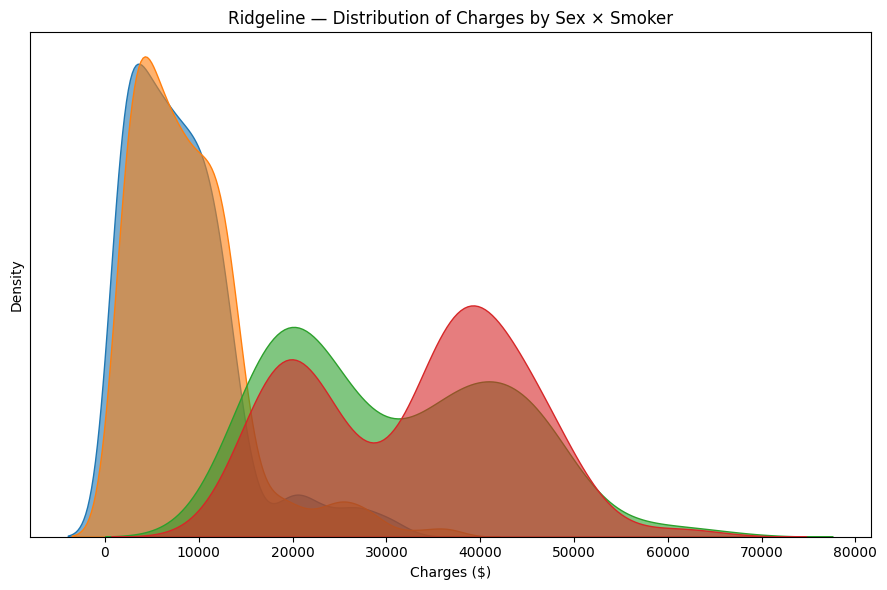

In [31]:
d = df.copy()
d["sex"] = d["sex"].astype(str).str.lower().str.strip()
d["smoker"] = d["smoker"].astype(str).str.lower().str.strip()
d["charges"] = pd.to_numeric(d["charges"], errors="coerce")
d = d.dropna(subset=["sex","smoker","charges"])

d["group"] = d["sex"].str.capitalize() + " | " + d["smoker"].map({"yes":"Smoker","no":"Non-smoker"})
order = d.groupby("group")["charges"].median().sort_values().index.tolist()


plt.figure(figsize=(9,6))
offset = 0
step = 1.2
for grp in order:
    vals = d.loc[d["group"]==grp, "charges"]
    sns.kdeplot(vals, bw_method="scott", fill=True, alpha=0.6, linewidth=1)
    # Offset y-axis by setting ylim and annotate
    if plt.gca().lines: # Check if there are any lines before accessing
        y = plt.gca().lines[-1].get_ydata()
        x = plt.gca().lines[-1].get_xdata()
        plt.gca().lines[-1].set_ydata(y + offset)
        for c in plt.gca().collections[-1].get_paths():
            c.vertices[:,1] = c.vertices[:,1] + offset
        plt.text(vals.quantile(0.9), offset + max(y)*0.9, grp, fontsize=10)
        offset += step

plt.title("Ridgeline — Distribution of Charges by Sex × Smoker")
plt.xlabel("Charges ($)")
plt.yticks([]); plt.tight_layout()
plt.show()

In [32]:
g = df.groupby(["region", "sex"])["charges"].mean().reset_index()
g_pivot = g.pivot(index="region", columns="sex", values="charges")

# compute absolute & % gap
g_pivot["gap_$"] = g_pivot["female"] - g_pivot["male"]
g_pivot["gap_%"] = (g_pivot["female"] / g_pivot["male"] - 1) * 100

# --- Grouped bar (mean charge by region & sex) ---
fig1 = go.Figure()
for s, color in zip(["male", "female"], ["#636EFA", "#EF553B"]):
    fig1.add_trace(go.Bar(
        x=g_pivot.index,
        y=g_pivot[s],
        name=s.capitalize(),
        marker_color=color,
        text=[f"${v:,.0f}" for v in g_pivot[s]],
        textposition="outside"
    ))
fig1.update_layout(
    title="Mean Medical Charges by Region and Gender",
    xaxis_title="Region",
    yaxis_title="Mean Charges ($)",
    barmode="group",
    template="plotly_white",
    height=520
)
fig1.show()

# --- 2️⃣ Relative Gap Bar (% uplift of female vs male) ---
fig2 = go.Figure(go.Bar(
    x=g_pivot.index,
    y=g_pivot["gap_%"],
    marker_color=["#D62728" if v>0 else "#1F77B4" for v in g_pivot["gap_%"]],
    text=[f"{v:+.1f}%" for v in g_pivot["gap_%"]],
    textposition="outside"
))
fig2.update_layout(
    title="Female − Male Mean Charge Gap by Region (%)",
    xaxis_title="Region",
    yaxis_title="% Difference (Female vs Male)",
    template="plotly_white",
    height=480
)
fig2.show()

## **Children**

In [33]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Children Distribution', 'Avg Charges by Children',
                    'Children by Smoker Status'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}, {'type': 'bar'}]]
)

# Children distribution
children_counts = df['children'].value_counts().sort_index()
fig.add_trace(go.Bar(x=children_counts.index, y=children_counts.values,
                     name='Count'), row=1, col=1)

# Average charges by number of children
avg_charges_children = df.groupby('children')['charges'].mean()
fig.add_trace(go.Bar(x=avg_charges_children.index, y=avg_charges_children.values,
                     name='Avg Charges'), row=1, col=2)

# Children by smoker status
children_smoker = pd.crosstab(df['children'], df['smoker'])
fig.add_trace(go.Bar(x=children_smoker.index, y=children_smoker['yes'],
                     name='Smoker'), row=1, col=3)
fig.add_trace(go.Bar(x=children_smoker.index, y=children_smoker['no'],
                     name='Non-Smoker'), row=1, col=3)

fig.update_layout(height=400, title_text="Children Analysis")
fig.show()

print("\nAverage charges by children:")
print(avg_charges_children)


Average charges by children:
children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


##**Region**

In [34]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Region Distribution', 'Charges by Region (Box)',
                    'Smokers by Region', 'BMI by Region'),
    specs=[[{'type': 'bar'}, {'type': 'box'}],
           [{'type': 'bar'}, {'type': 'box'}]]
)

# Region distribution
region_counts = df['region'].value_counts()
fig.add_trace(go.Bar(x=region_counts.index, y=region_counts.values), row=1, col=1)

# Charges by region
for region in df['region'].unique():
    region_data = df[df['region'] == region]['charges']
    fig.add_trace(go.Box(y=region_data, name=region), row=1, col=2)

# Smokers by region
smoker_region = pd.crosstab(df['region'], df['smoker'])
fig.add_trace(go.Bar(x=smoker_region.index, y=smoker_region['yes'],
                     name='Smokers'), row=2, col=1)
fig.add_trace(go.Bar(x=smoker_region.index, y=smoker_region['no'],
                     name='Non-Smokers'), row=2, col=1)

# BMI by region
for region in df['region'].unique():
    region_data = df[df['region'] == region]['bmi']
    fig.add_trace(go.Box(y=region_data, name=region), row=2, col=2)

fig.update_layout(height=800, title_text="Comprehensive Region Analysis")
fig.show()

# Statistical test for regional differences
print("\nANOVA Test for Charges across Regions:")
regions_charges = [df[df['region'] == r]['charges'].values for r in df['region'].unique()]
f_stat, p_value = f_oneway(*regions_charges)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference in charges across regions")
else:
    print("No significant difference in charges across regions")



ANOVA Test for Charges across Regions:
F-statistic: 2.9696, p-value: 0.0309
Significant difference in charges across regions


# **Feature Engineering**

In [35]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_raw,sex_raw,smoker_bin,sex_bin,Age_Group
0,19,female,27.900,0,yes,southwest,16884.92400,yes,female,1,0,Young
1,18,male,33.770,1,no,southeast,1725.55230,no,male,0,1,Young
2,28,male,33.000,3,no,southeast,4449.46200,no,male,0,1,Young
3,33,male,22.705,0,no,northwest,21984.47061,no,male,0,1,Young Adults
4,32,male,28.880,0,no,northwest,3866.85520,no,male,0,1,Young Adults
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,no,male,0,1,Senior
1334,18,female,31.920,0,no,northeast,2205.98080,no,female,0,0,Young
1335,18,female,36.850,0,no,southeast,1629.83350,no,female,0,0,Young
1336,21,female,25.800,0,no,southwest,2007.94500,no,female,0,0,Young


In [36]:
bmi_bins   = [0,18.5,25,30,35,40,1e9]
bmi_labels = ["Under","Normal","Overwt","Obese I","Obese II","Obese III"]
df["bmi_class"] = pd.cut(df["bmi"], bmi_bins, labels=bmi_labels, right=False)


In [37]:
df["age_c"] = df["age"] - df["age"].mean()
df["bmi_c"] = df["bmi"] - df["bmi"].mean()
df["age_sq"] = df["age_c"]**2
df["bmi_sq"] = df["bmi_c"]**2
df["age_h59"]  = (df["age"] - 59).clip(lower=0)
df["bmi_h25"]  = (df["bmi"] - 25).clip(lower=0)
df["bmi_h30"]  = (df["bmi"] - 30).clip(lower=0)
df["bmi_h35"]  = (df["bmi"] - 35).clip(lower=0)

In [38]:
df["smoker_raw"] = df["smoker"]
df["sex_raw"]    = df["sex"]

def to01_yesno(s):
    s = s.astype(str).str.strip().str.lower()
    return s.map({"yes":1,"y":1,"true":1,"1":1, "no":0,"n":0,"false":0,"0":0})

def to01_malefemale(s):
    s = s.astype(str).str.strip().str.lower()
    return s.map({"male":1,"m":1, "female":0,"f":0})

# Only encode if not already numeric (guards against re-runs)
if not pd.api.types.is_numeric_dtype(df["smoker"]):
    df["smoker"] = to01_yesno(df["smoker"]).astype("Int64")
else:
    df["smoker"] = df["smoker"].fillna(0).astype("Int64")
if not pd.api.types.is_numeric_dtype(df["sex"]):
    df["sex"] = to01_malefemale(df["sex"]).astype("Int64")
else:
    df["sex"] = df["sex"].fillna(0).astype("Int64")

print("Unmapped smoker:", df.loc[df["smoker"].isna(), "smoker_raw"].unique())
print("Unmapped sex:",    df.loc[df["sex"].isna(),    "sex_raw"].unique())

if "age_h59" not in df.columns:
    df["age_h59"] = (df["age"] - 59).clip(lower=0)
if "bmi_h30" not in df.columns:
    df["bmi_h30"] = (df["bmi"] - 30).clip(lower=0)


df["smoker_x_age"]      = df["smoker"] * df["age"]
df["smoker_x_bmi"]      = df["smoker"] * df["bmi"]
df["age_x_bmi"]         = df["age"] * df["bmi"]
df["smoker_x_age_h59"]  = df["smoker"] * df["age_h59"]
df["smoker_x_bmi_h30"]  = df["smoker"] * df["bmi_h30"]


Unmapped smoker: []
Unmapped sex: []


In [39]:
df["charges"] = pd.to_numeric(df["charges"], errors="coerce")
df["Age_Group"] = df["Age_Group"].astype("string")
df["bmi_class"] = df["bmi_class"].astype("string")

smoker_str = df["smoker"].map({1: "yes", 0: "no"}).fillna("unk").astype("string")

df["risk_cell"] = (
    df["Age_Group"].fillna("unk").astype("string") + "|" +
    df["bmi_class"].fillna("unk").astype("string") + "|" +
    smoker_str
)

cell = df.groupby("risk_cell", dropna=False)["charges"].agg(n="size", cell_mean="mean").reset_index()
overall = df["charges"].mean()
k = 30.0
cell["Z"] = cell["n"] / (cell["n"] + k)
cell["cell_mean_cred"] = cell["Z"]*cell["cell_mean"] + (1 - cell["Z"])*overall
df = df.merge(cell[["risk_cell","cell_mean_cred"]], on="risk_cell", how="left")


In [40]:
def object_to_int(dataframe_series):
    if dataframe_series.dtype=='object' or dataframe_series.dtype=='string':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series
df = df.apply(lambda x: object_to_int(x))
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_raw,sex_raw,smoker_bin,...,bmi_h25,bmi_h30,bmi_h35,smoker_x_age,smoker_x_bmi,age_x_bmi,smoker_x_age_h59,smoker_x_bmi_h30,risk_cell,cell_mean_cred
0,19,0,27.900,0,1,3,16884.92400,1,0,1,...,2.90,0.00,0.0,19,27.9,530.100,0,0.0,43,15470.537169
1,18,1,33.770,1,0,2,1725.55230,0,1,0,...,8.77,3.77,0.0,0,0.0,607.860,0,0.0,40,6866.572188
2,28,1,33.000,3,0,2,4449.46200,0,1,0,...,8.00,3.00,0.0,0,0.0,924.000,0,0.0,40,6866.572188
3,33,1,22.705,0,0,1,21984.47061,0,1,0,...,0.00,0.00,0.0,0,0.0,749.265,0,0.0,22,9940.714170
4,32,1,28.880,0,0,1,3866.85520,0,1,0,...,3.88,0.00,0.0,0,0.0,924.160,0,0.0,30,7967.338440


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

SEED = 2025

# ========== 1) X, y ==========
X = df.drop(columns=[c for c in ["charges","cell_mean_cred"] if c in df.columns]).copy()
y = df["charges"].values


if not pd.api.types.is_numeric_dtype(X["smoker"]):
    X["smoker"] = (X["smoker"].astype(str).str.strip().str.lower()
                   .map({"yes":1,"y":1,"true":1,"1":1, "no":0,"n":0,"false":0,"0":0})).fillna(0).astype(int)
else:
    X["smoker"] = X["smoker"].fillna(0).astype(int)

# ========== 2) Train/Test split ==========
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, shuffle=True)

# ========== 3) KMeans ==========
# risk space: scale age/bmi/children + smoker passthrough
risk_num = ["age","bmi","children"]
risk_bin = "smoker"


km_old = [c for c in X_tr.columns if c.startswith("km_")]
X_tr = X_tr.drop(columns=km_old, errors="ignore")
X_te = X_te.drop(columns=km_old, errors="ignore")

# scale train-only
scaler_km = StandardScaler().fit(X_tr[risk_num].astype(float))
Xnum_tr = scaler_km.transform(X_tr[risk_num].astype(float))
Xnum_te = scaler_km.transform(X_te[risk_num].astype(float))

s_tr = X_tr[risk_bin].astype(int).to_numpy().reshape(-1,1)
s_te = X_te[risk_bin].astype(int).to_numpy().reshape(-1,1)

Xk_tr = np.column_stack([Xnum_tr, s_tr])
Xk_te = np.column_stack([Xnum_te, s_te])


km = KMeans(n_clusters=4, random_state=SEED, n_init="auto").fit(Xk_tr)


X_tr = X_tr.copy()
X_te = X_te.copy()

X_tr["km_cluster"] = km.predict(Xk_tr)
X_te["km_cluster"] = km.predict(Xk_te)

D_tr = km.transform(Xk_tr)
D_te = km.transform(Xk_te)
for j in range(km.n_clusters):
    X_tr[f"km_dist_{j}"] = D_tr[:, j]
    X_te[f"km_dist_{j}"] = D_te[:, j]

print("Shapes ->",
      "X_tr:", X_tr.shape, "| X_te:", X_te.shape,
      "| y_tr:", y_tr.shape, "| y_te:", y_te.shape)


Shapes -> X_tr: (1070, 31) | X_te: (268, 31) | y_tr: (1070,) | y_te: (268,)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   Int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   Int64  
 5   region            1338 non-null   int64  
 6   charges           1338 non-null   float64
 7   smoker_raw        1338 non-null   int64  
 8   sex_raw           1338 non-null   int64  
 9   smoker_bin        1338 non-null   Int64  
 10  sex_bin           1338 non-null   Int64  
 11  Age_Group         1338 non-null   int64  
 12  bmi_class         1338 non-null   int64  
 13  age_c             1338 non-null   float64
 14  bmi_c             1338 non-null   float64
 15  age_sq            1338 non-null   float64
 16  bmi_sq            1338 non-null   float64


# **Machine learning**

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor, TweedieRegressor)
# Neighbors / SVM / MLP
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
# Trees & Ensembles
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor, AdaBoostRegressor)
# Baseline
from sklearn.dummy import DummyRegressor

# Optional GBMs
have_xgb = have_lgbm = have_cat = False
try:
    from xgboost import XGBRegressor
    have_xgb = True
except Exception:
    pass
try:
    from lightgbm import LGBMRegressor
    have_lgbm = True
except Exception:
    pass
try:
    from catboost import CatBoostRegressor
    have_cat = True
except Exception:
    pass

def with_scaler(est):
    return Pipeline([("scale", StandardScaler()), ("mdl", est)])

ridge_pca = Pipeline([
    ("scale", StandardScaler()),
    ("pca",   PCA(n_components=0.95, random_state=SEED)),
    ("mdl",   Ridge())
])

models = [
    ("BaselineMean",     DummyRegressor(strategy="mean")),
    ("LinearRegression", with_scaler(LinearRegression())),
    ("Ridge+PCA",        ridge_pca),
    ("Ridge",            with_scaler(Ridge())),
    ("Lasso",            with_scaler(Lasso(random_state=SEED, max_iter=20000))),
    ("ElasticNet",       with_scaler(ElasticNet(random_state=SEED, max_iter=20000))),
    ("BayesianRidge",    with_scaler(BayesianRidge())),
    ("HuberRegressor",   with_scaler(HuberRegressor())),
    ("Tweedie(log)",     with_scaler(TweedieRegressor(power=1.5, alpha=1.0))),

    ("KNN",              with_scaler(KNeighborsRegressor())),
    ("SVR(RBF)",         with_scaler(SVR(kernel="rbf", C=1.0))),

    ("MLP",              with_scaler(MLPRegressor(hidden_layer_sizes=(128,64),
                                                 activation="relu", solver="adam",
                                                 learning_rate_init=1e-3, alpha=1e-4,
                                                 max_iter=500, early_stopping=True,
                                                 random_state=SEED))),

    ("DecisionTree",     DecisionTreeRegressor(random_state=SEED)),
    ("RandomForest",     RandomForestRegressor(random_state=SEED, n_estimators=600, n_jobs=-1)),
    ("ExtraTrees",       ExtraTreesRegressor(random_state=SEED, n_estimators=600, n_jobs=-1)),
    ("GradientBoosting", GradientBoostingRegressor(random_state=SEED)),
    ("HistGradientBoosting", HistGradientBoostingRegressor(random_state=SEED)),
    ("AdaBoost",         AdaBoostRegressor(random_state=SEED)),
]

if have_xgb:
    models.append(("XGBoost",  XGBRegressor(random_state=SEED, objective="reg:squarederror", tree_method="hist")))
if have_lgbm:
    models.append(("LightGBM", LGBMRegressor(random_state=SEED)))
if have_cat:
    models.append(("CatBoost", CatBoostRegressor(random_state=SEED, verbose=False, loss_function="RMSE")))

def eval_train_test(name, est):
    est.fit(X_tr, y_tr)
    # train
    yhat_tr = est.predict(X_tr)
    mae_tr  = mean_absolute_error(y_tr, yhat_tr)
    rmse_tr = (mean_squared_error(y_tr, yhat_tr)) ** 0.5
    r2_tr   = r2_score(y_tr, yhat_tr)
    # test
    yhat_te = est.predict(X_te)
    mae_te  = mean_absolute_error(y_te, yhat_te)
    rmse_te = (mean_squared_error(y_te, yhat_te)) ** 0.5
    r2_te   = r2_score(y_te, yhat_te)
    return {
        "model": name,
        "train_MAE": mae_tr, "train_RMSE": rmse_tr, "train_R2": r2_tr,
        "test_MAE":  mae_te, "test_RMSE":  rmse_te, "test_R2":  r2_te,
    }

import pandas as pd
results = pd.DataFrame([eval_train_test(n, m) for n, m in models]).sort_values("test_MAE")
print(results.reset_index(drop=True))


                   model    train_MAE    train_RMSE  train_R2     test_MAE  \
0         HuberRegressor  2099.506767   5128.564893  0.820755  2046.222062   
1       GradientBoosting  1751.578195   3209.612853  0.929796  2471.557029   
2           RandomForest   993.464098   1875.136670  0.976038  2623.643793   
3             ExtraTrees    29.572515    494.205984  0.998336  2637.652994   
4   HistGradientBoosting  1290.583808   2217.873571  0.966478  2739.592856   
5                    KNN  2340.760066   4190.590471  0.880324  2790.525918   
6                  Lasso  2768.477978   4700.600914  0.849422  2803.598713   
7       LinearRegression  2769.998666   4700.411938  0.849434  2804.479394   
8                    MLP  2779.914378   4660.287394  0.851994  2827.426280   
9                  Ridge  2785.770291   4705.199435  0.849127  2827.589767   
10         BayesianRidge  2801.876580   4713.139859  0.848617  2845.055188   
11          Tweedie(log)  2890.116322   4827.245959  0.841199  2

In [44]:
# ============================================================
# Full script: No-CV Tuning (holdout) + Top-3 Blending (2 & 3)
# Prints best_params for each model and final TEST metrics
# ============================================================

import numpy as np, pandas as pd, copy, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import loguniform, randint, uniform

from sklearn.linear_model import HuberRegressor, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.base import clone

# --------------- Config & Utils ---------------
SEED = 2025
rng = np.random.default_rng(SEED)

def rmse(y_true, y_pred):
    from sklearn.metrics import mean_squared_error
    return np.sqrt(mean_squared_error(y_true, y_pred))

def _mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Try to obtain X_tr, X_te, y_tr, y_te from the environment; else prepare them.
def _get_train_test_split():
    g = globals()
    # (1) If user already has prepared splits, just use them
    if all(k in g for k in ["X_tr", "X_te", "y_tr", "y_te"]):
        print("[Info] Using existing X_tr/X_te/y_tr/y_te from globals.")
        return g["X_tr"], g["X_te"], g["y_tr"], g["y_te"]

    # (2) If user provided a DataFrame 'df' and string 'TARGET_COL'
    if "df" in g and "TARGET_COL" in g and isinstance(g["TARGET_COL"], str):
        print(f"[Info] Building train/test from df with TARGET_COL='{g['TARGET_COL']}'.")
        _df = g["df"].copy()
        # Drop rows with NA in target
        _df = _df[_df[g["TARGET_COL"]].notna()]
        y = _df[g["TARGET_COL"]].astype(float).values
        X = _df.drop(columns=[g["TARGET_COL"]])
        # Basic numeric-only handling; user can customize as needed
        X = X.select_dtypes(include=[np.number]).astype(float)
        X_tr, X_te, y_tr, y_te = train_test_split(X.values, y, test_size=0.2, random_state=SEED, shuffle=True)
        return X_tr, X_te, y_tr, y_te

    # (3) Fallback: synthetic data so script runs out-of-the-box
    print("[Info] No user data found. Generating synthetic regression dataset.")
    from sklearn.datasets import make_regression
    X, y = make_regression(
        n_samples=500, n_features=15, n_informative=8, noise=12.0, random_state=SEED
    )
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, shuffle=True)
    return X_tr, X_te, y_tr, y_te

# --------------- Models & Spaces ---------------
huber = Pipeline([("sc", StandardScaler()), ("mdl", HuberRegressor())])
lasso = Pipeline([("sc", StandardScaler()), ("mdl", Lasso(max_iter=50000, random_state=SEED))])
gbr  = GradientBoostingRegressor(loss="absolute_error", random_state=SEED)  # optimize MAE-like objective
rf   = RandomForestRegressor(random_state=SEED, n_jobs=-1)
et   = ExtraTreesRegressor(random_state=SEED, n_jobs=-1)

estimators = {
    "HuberRegressor": huber,
    "GradientBoosting": gbr,
    "RandomForest": rf,
    "Lasso": lasso,
    "ExtraTrees": et,
}

param_spaces = {
    "HuberRegressor": {
        "mdl__epsilon": [1.05, 1.1, 1.2, 1.35, 1.5, 1.8, 2.0],
        "mdl__alpha":   loguniform(1e-6, 1e0),
        "mdl__max_iter": randint(4000, 20000),
        "mdl__tol":     loguniform(1e-6, 1e-2),
        "mdl__fit_intercept": [True, False],
    },
    "GradientBoosting": {
        "n_estimators":   randint(500, 1800),
        "learning_rate":  loguniform(1e-3, 2e-1),
        "max_depth":      randint(2, 6),
        "min_samples_leaf":  randint(1, 40),
        "min_samples_split": randint(2, 100),
        "subsample":      uniform(0.6, 0.4),
        "max_features":   ["sqrt", "log2", None],
    },
    "RandomForest": {
        "n_estimators":   randint(600, 1800),
        "max_depth":      [None] + list(range(6, 26, 2)),
        "min_samples_leaf":  randint(1, 40),
        "min_samples_split": randint(2, 100),
        "max_features":   ["sqrt", "log2", None],
        "bootstrap":      [True, False],
    },
    "Lasso": {
        "mdl__alpha":     loguniform(1e-4, 1e1),
        "mdl__selection": ["cyclic", "random"],
        "mdl__fit_intercept": [True, False],
    },
    "ExtraTrees": {
        "n_estimators":   randint(600, 1800),
        "max_depth":      [None] + list(range(6, 26, 2)),
        "min_samples_leaf":  randint(1, 40),
        "min_samples_split": randint(2, 100),
        "max_features":   ["sqrt", "log2", None],
        "bootstrap":      [False, True],
    },
}

# --------------- Data Prep ---------------
X_tr, X_te, y_tr, y_te = _get_train_test_split()

# Split TRAIN into sub-train / valid for holdout tuning & blending weight search
X_tr_sub, X_va_sub, y_tr_sub, y_va_sub = train_test_split(
    X_tr, y_tr, test_size=0.25, random_state=SEED, shuffle=True
)

# --------------- Random Search (No-CV, Holdout) ---------------
def _sample_one(spec, rng):
    # scipy.stats distributions expose .rvs
    if hasattr(spec, "rvs"):
        return spec.rvs(random_state=SEED)  # keep seed stable across draws
    if isinstance(spec, (list, tuple)):
        return rng.choice(list(spec))
    return spec

# For params that must be integers
_INT_KEYS = {
    "n_estimators", "max_depth", "min_samples_leaf", "min_samples_split", "mdl__max_iter"
}

def _draw_params(space: dict, rng):
    params = {}
    for k, v in space.items():
        val = _sample_one(v, rng)
        if k in _INT_KEYS and val is not None:
            try:
                val = int(val)
            except Exception:
                pass
        params[k] = val
    return params

def tune_no_cv(name, est, space, n_iter=80):
    print(f">>> Tuning (no-CV, holdout) : {name} | n_iter={n_iter}", flush=True)
    best = {"score": np.inf, "params": None, "est_sub": None, "est_full": None}
    for i in range(1, n_iter+1):
        params = _draw_params(space, rng)
        model = clone(est).set_params(**params)
        try:
            model.fit(X_tr_sub, y_tr_sub)               # fit on sub-train
            pred_val = model.predict(X_va_sub)          # score on valid
            mae = _mae(y_va_sub, pred_val)
        except Exception:
            # skip bad configs
            continue

        if mae < best["score"]:
            best["score"] = mae
            best["params"] = params
            best["est_sub"] = model  # fitted on sub-train for blending weight search

        if i % max(1, n_iter // 5) == 0 or i == n_iter:
            print(f"  - iter {i:>3}/{n_iter}: current best valid MAE={best['score']:.4f}", flush=True)

    if best["params"] is None:
        raise RuntimeError(f"Tuning failed for {name} – no valid parameter set found.")

    # Refit best on FULL TRAIN for final test evaluation
    est_full = clone(est).set_params(**best["params"])
    est_full.fit(X_tr, y_tr)
    best["est_full"] = est_full

    print(f"<<< Done: {name} | best valid MAE={best['score']:.4f}")
    print(f"    best_params[{name}] = {best['params']}")
    return best

# Run tuning for all models
tuned = {}
for name, est in estimators.items():
    tuned[name] = tune_no_cv(name, est, param_spaces[name], n_iter=80)

print("\n=== Best params by model (no-CV, holdout) ===")
for name, res in tuned.items():
    print(f"- {name}: {res['params']}")

# --------------- Single-Model TEST Evaluation ---------------
rows = []
for name, res in tuned.items():
    mdl = res["est_full"]
    yhat = mdl.predict(X_te)
    rows.append({
        "model": name,
        "test_MAE": mean_absolute_error(y_te, yhat),
        "test_RMSE": rmse(y_te, yhat),
        "test_R2": r2_score(y_te, yhat)
    })
single_df = pd.DataFrame(rows).sort_values("test_MAE")
print("\n=== Single-model (tuned, no-CV) on TEST ===")
print(single_df.reset_index(drop=True))

# --------------- Blending on VALID (weights) ---------------
fitted_sub = {name: res["est_sub"] for name, res in tuned.items()}

def tune_blend_two(name1, name2, step=0.05):
    print(f">>> Tuning blend-2: {name1} + {name2}", flush=True)
    p1 = fitted_sub[name1].predict(X_va_sub)
    p2 = fitted_sub[name2].predict(X_va_sub)
    ws = np.arange(0.0, 1.0 + 1e-9, step)
    best = (1e18, None)
    for w in ws:
        pred = w*p1 + (1-w)*p2
        mae = mean_absolute_error(y_va_sub, pred)
        if mae < best[0]:
            best = (mae, w)
    print(f"<<< Done blend-2: best MAE={best[0]:.4f}, "
          f"w({name1})={best[1]:.2f}, w({name2})={1-best[1]:.2f}")
    return best[1]

def tune_blend_three(n1, n2, n3, step=0.1):
    print(f">>> Tuning blend-3: {n1} + {n2} + {n3}", flush=True)
    p1 = fitted_sub[n1].predict(X_va_sub)
    p2 = fitted_sub[n2].predict(X_va_sub)
    p3 = fitted_sub[n3].predict(X_va_sub)
    grid = np.arange(0.0, 1.0 + 1e-9, step)
    best = (1e18, None, None, None)
    for a in grid:
        for b in grid:
            c = 1 - a - b
            if c < -1e-9 or c > 1.0:
                continue
            pred = a*p1 + b*p2 + c*p3
            mae = mean_absolute_error(y_va_sub, pred)
            if mae < best[0]:
                best = (mae, a, b, c)
    print(f"<<< Done blend-3: best MAE={best[0]:.4f}, "
          f"weights=({best[1]:.2f},{best[2]:.2f},{best[3]:.2f})")
    return best[1], best[2], best[3]

# pick top-3 from single models by MAE
top_names = list(single_df["model"].head(3))
if len(top_names) < 3:
    top_names = list(single_df["model"].head(min(3, len(single_df))))

w12 = tune_blend_two(top_names[0], top_names[1], step=0.05)
w13 = tune_blend_two(top_names[0], top_names[2], step=0.05)
w1, w2, w3 = tune_blend_three(top_names[0], top_names[1], top_names[2], step=0.1)

# --------------- Evaluate Blends on TEST ---------------
pred_test = {name: tuned[name]["est_full"].predict(X_te) for name in tuned.keys()}

def blend2_on_test(n1, n2, w):
    yb = w*pred_test[n1] + (1-w)*pred_test[n2]
    return {
        "model": f"BLEND2({n1},{n2})",
        "test_MAE": mean_absolute_error(y_te, yb),
        "test_RMSE": rmse(y_te, yb),
        "test_R2": r2_score(y_te, yb),
        "weights": {n1: round(w, 3), n2: round(1-w, 3)}
    }

def blend3_on_test(n1, n2, n3, w1, w2, w3):
    yb = w1*pred_test[n1] + w2*pred_test[n2] + w3*pred_test[n3]
    return {
        "model": f"BLEND3({n1},{n2},{n3})",
        "test_MAE": mean_absolute_error(y_te, yb),
        "test_RMSE": rmse(y_te, yb),
        "test_R2": r2_score(y_te, yb),
        "weights": {n1: round(w1, 3), n2: round(w2, 3), n3: round(w3, 3)}
    }

blend_rows = []
blend_rows.append(blend2_on_test(top_names[0], top_names[1], w12))
blend_rows.append(blend2_on_test(top_names[0], top_names[2], w13))
blend_rows.append(blend3_on_test(top_names[0], top_names[1], top_names[2], w1, w2, w3))

blend_df = pd.DataFrame(blend_rows).sort_values("test_MAE")
print("\n=== Blends on TEST (tuned no-CV) ===")
print(blend_df[["model","test_MAE","test_RMSE","test_R2","weights"]].reset_index(drop=True))


[Info] Using existing X_tr/X_te/y_tr/y_te from globals.
>>> Tuning (no-CV, holdout) : HuberRegressor | n_iter=80
  - iter  16/80: current best valid MAE=2293.0557
  - iter  32/80: current best valid MAE=2293.0557
  - iter  48/80: current best valid MAE=2293.0557
  - iter  64/80: current best valid MAE=2293.0557
  - iter  80/80: current best valid MAE=2293.0557
<<< Done: HuberRegressor | best valid MAE=2293.0557
    best_params[HuberRegressor] = {'mdl__epsilon': np.float64(1.2), 'mdl__alpha': np.float64(6.500233866865241e-06), 'mdl__max_iter': 10718, 'mdl__tol': np.float64(3.482993425718961e-06), 'mdl__fit_intercept': np.True_}
>>> Tuning (no-CV, holdout) : GradientBoosting | n_iter=80
  - iter  16/80: current best valid MAE=3340.5970
  - iter  32/80: current best valid MAE=3340.5970
  - iter  48/80: current best valid MAE=3340.5970
  - iter  64/80: current best valid MAE=3340.5970
  - iter  80/80: current best valid MAE=3340.5970
<<< Done: GradientBoosting | best valid MAE=3340.5970
  

In [45]:
# ============================================================
# Full script: No-CV Tuning (holdout) + Top-3 Blending (2 & 3)
# Prints best_params for each model and final TEST metrics
# n_iter = 500
# ============================================================

import numpy as np, pandas as pd, copy, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import loguniform, randint, uniform

from sklearn.linear_model import HuberRegressor, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.base import clone

# --------------- Config & Utils ---------------
SEED = 2025
rng = np.random.default_rng(SEED)

def rmse(y_true, y_pred):
    from sklearn.metrics import mean_squared_error
    return np.sqrt(mean_squared_error(y_true, y_pred))

def _mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Try to obtain X_tr, X_te, y_tr, y_te from the environment; else prepare them.
def _get_train_test_split():
    g = globals()
    # (1) If user already has prepared splits, just use them
    if all(k in g for k in ["X_tr", "X_te", "y_tr", "y_te"]):
        print("[Info] Using existing X_tr/X_te/y_tr/y_te from globals.")
        return g["X_tr"], g["X_te"], g["y_tr"], g["y_te"]

    # (2) If user provided a DataFrame 'df' and string 'TARGET_COL'
    if "df" in g and "TARGET_COL" in g and isinstance(g["TARGET_COL"], str):
        print(f"[Info] Building train/test from df with TARGET_COL='{g['TARGET_COL']}'.")
        _df = g["df"].copy()
        # Drop rows with NA in target
        _df = _df[_df[g["TARGET_COL"]].notna()]
        y = _df[g["TARGET_COL"]].astype(float).values
        X = _df.drop(columns=[g["TARGET_COL"]])
        # Basic numeric-only handling; user can customize as needed
        X = X.select_dtypes(include=[np.number]).astype(float)
        X_tr, X_te, y_tr, y_te = train_test_split(X.values, y, test_size=0.2, random_state=SEED, shuffle=True)
        return X_tr, X_te, y_tr, y_te

    # (3) Fallback: synthetic data so script runs out-of-the-box
    print("[Info] No user data found. Generating synthetic regression dataset.")
    from sklearn.datasets import make_regression
    X, y = make_regression(
        n_samples=500, n_features=15, n_informative=8, noise=12.0, random_state=SEED
    )
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, shuffle=True)
    return X_tr, X_te, y_tr, y_te

# --------------- Models & Spaces ---------------
huber = Pipeline([("sc", StandardScaler()), ("mdl", HuberRegressor())])
lasso = Pipeline([("sc", StandardScaler()), ("mdl", Lasso(max_iter=50000, random_state=SEED))])
gbr  = GradientBoostingRegressor(loss="absolute_error", random_state=SEED)  # optimize MAE-like objective
rf   = RandomForestRegressor(random_state=SEED, n_jobs=-1)
et   = ExtraTreesRegressor(random_state=SEED, n_jobs=-1)

estimators = {
    "HuberRegressor": huber,
    "GradientBoosting": gbr,
    "RandomForest": rf,
    "Lasso": lasso,
    "ExtraTrees": et,
}

param_spaces = {
    "HuberRegressor": {
        "mdl__epsilon": [1.05, 1.1, 1.2, 1.35, 1.5, 1.8, 2.0],
        "mdl__alpha":   loguniform(1e-6, 1e0),
        "mdl__max_iter": randint(4000, 20000),
        "mdl__tol":     loguniform(1e-6, 1e-2),
        "mdl__fit_intercept": [True, False],
    },
    "GradientBoosting": {
        "n_estimators":   randint(500, 1800),
        "learning_rate":  loguniform(1e-3, 2e-1),
        "max_depth":      randint(2, 6),
        "min_samples_leaf":  randint(1, 40),
        "min_samples_split": randint(2, 100),
        "subsample":      uniform(0.6, 0.4),
        "max_features":   ["sqrt", "log2", None],
    },
    "RandomForest": {
        "n_estimators":   randint(600, 1800),
        "max_depth":      [None] + list(range(6, 26, 2)),
        "min_samples_leaf":  randint(1, 40),
        "min_samples_split": randint(2, 100),
        "max_features":   ["sqrt", "log2", None],
        "bootstrap":      [True, False],
    },
    "Lasso": {
        "mdl__alpha":     loguniform(1e-4, 1e1),
        "mdl__selection": ["cyclic", "random"],
        "mdl__fit_intercept": [True, False],
    },
    "ExtraTrees": {
        "n_estimators":   randint(600, 1800),
        "max_depth":      [None] + list(range(6, 26, 2)),
        "min_samples_leaf":  randint(1, 40),
        "min_samples_split": randint(2, 100),
        "max_features":   ["sqrt", "log2", None],
        "bootstrap":      [False, True],
    },
}

# --------------- Data Prep ---------------
X_tr, X_te, y_tr, y_te = _get_train_test_split()

# Split TRAIN into sub-train / valid for holdout tuning & blending weight search
X_tr_sub, X_va_sub, y_tr_sub, y_va_sub = train_test_split(
    X_tr, y_tr, test_size=0.25, random_state=SEED, shuffle=True
)

# --------------- Random Search (No-CV, Holdout) ---------------
def _sample_one(spec, rng):
    # scipy.stats distributions expose .rvs
    if hasattr(spec, "rvs"):
        # draw with a fresh but reproducible seed each time
        return spec.rvs(random_state=int(rng.integers(0, 2**31-1)))
    if isinstance(spec, (list, tuple)):
        return rng.choice(list(spec))
    return spec

# For params that must be integers
_INT_KEYS = {
    "n_estimators", "max_depth", "min_samples_leaf", "min_samples_split", "mdl__max_iter"
}

def _draw_params(space: dict, rng):
    params = {}
    for k, v in space.items():
        val = _sample_one(v, rng)
        if k in _INT_KEYS and val is not None:
            try:
                val = int(val)
            except Exception:
                pass
        params[k] = val
    return params

def tune_no_cv(name, est, space, n_iter=500):
    print(f">>> Tuning (no-CV, holdout) : {name} | n_iter={n_iter}", flush=True)
    best = {"score": np.inf, "params": None, "est_sub": None, "est_full": None}
    for i in range(1, n_iter+1):
        params = _draw_params(space, rng)
        model = clone(est).set_params(**params)
        try:
            model.fit(X_tr_sub, y_tr_sub)               # fit on sub-train
            pred_val = model.predict(X_va_sub)          # score on valid
            mae = _mae(y_va_sub, pred_val)
        except Exception:
            # skip bad configs
            continue

        if mae < best["score"]:
            best["score"] = mae
            best["params"] = params
            best["est_sub"] = model  # fitted on sub-train for blending weight search

        if i % max(1, n_iter // 5) == 0 or i == n_iter:
            print(f"  - iter {i:>3}/{n_iter}: current best valid MAE={best['score']:.4f}", flush=True)

    if best["params"] is None:
        raise RuntimeError(f"Tuning failed for {name} – no valid parameter set found.")

    # Refit best on FULL TRAIN for final test evaluation
    est_full = clone(est).set_params(**best["params"])
    est_full.fit(X_tr, y_tr)
    best["est_full"] = est_full

    print(f"<<< Done: {name} | best valid MAE={best['score']:.4f}")
    print(f"    best_params[{name}] = {best['params']}")
    return best

# Run tuning for all models (n_iter=300)
tuned = {}
for name, est in estimators.items():
    tuned[name] = tune_no_cv(name, est, param_spaces[name], n_iter=500)

print("\n=== Best params by model (no-CV, holdout) ===")
for name, res in tuned.items():
    print(f"- {name}: {res['params']}")

# --------------- Single-Model TEST Evaluation ---------------
rows = []
for name, res in tuned.items():
    mdl = res["est_full"]
    yhat = mdl.predict(X_te)
    rows.append({
        "model": name,
        "test_MAE": mean_absolute_error(y_te, yhat),
        "test_RMSE": rmse(y_te, yhat),
        "test_R2": r2_score(y_te, yhat)
    })
single_df = pd.DataFrame(rows).sort_values("test_MAE")
print("\n=== Single-model (tuned, no-CV) on TEST ===")
print(single_df.reset_index(drop=True))

# --------------- Blending on VALID (weights) ---------------
fitted_sub = {name: res["est_sub"] for name, res in tuned.items()}

def tune_blend_two(name1, name2, step=0.05):
    print(f">>> Tuning blend-2: {name1} + {name2}", flush=True)
    p1 = fitted_sub[name1].predict(X_va_sub)
    p2 = fitted_sub[name2].predict(X_va_sub)
    ws = np.arange(0.0, 1.0 + 1e-9, step)
    best = (1e18, None)
    for w in ws:
        pred = w*p1 + (1-w)*p2
        mae = mean_absolute_error(y_va_sub, pred)
        if mae < best[0]:
            best = (mae, w)
    print(f"<<< Done blend-2: best MAE={best[0]:.4f}, "
          f"w({name1})={best[1]:.2f}, w({name2})={1-best[1]:.2f}")
    return best[1]

def tune_blend_three(n1, n2, n3, step=0.1):
    print(f">>> Tuning blend-3: {n1} + {n2} + {n3}", flush=True)
    p1 = fitted_sub[n1].predict(X_va_sub)
    p2 = fitted_sub[n2].predict(X_va_sub)
    p3 = fitted_sub[n3].predict(X_va_sub)
    grid = np.arange(0.0, 1.0 + 1e-9, step)
    best = (1e18, None, None, None)
    for a in grid:
        for b in grid:
            c = 1 - a - b
            if c < -1e-9 or c > 1.0:
                continue
            pred = a*p1 + b*p2 + c*p3
            mae = mean_absolute_error(y_va_sub, pred)
            if mae < best[0]:
                best = (mae, a, b, c)
    print(f"<<< Done blend-3: best MAE={best[0]:.4f}, "
          f"weights=({best[1]:.2f},{best[2]:.2f},{best[3]:.2f})")
    return best[1], best[2], best[3]

# pick top-3 from single models by MAE
top_names = list(single_df["model"].head(3))
if len(top_names) < 3:
    top_names = list(single_df["model"].head(min(3, len(single_df))))

w12 = tune_blend_two(top_names[0], top_names[1], step=0.05)
w13 = tune_blend_two(top_names[0], top_names[2], step=0.05)
w1, w2, w3 = tune_blend_three(top_names[0], top_names[1], top_names[2], step=0.1)

# --------------- Evaluate Blends on TEST ---------------
pred_test = {name: tuned[name]["est_full"].predict(X_te) for name in tuned.keys()}

def blend2_on_test(n1, n2, w):
    yb = w*pred_test[n1] + (1-w)*pred_test[n2]
    return {
        "model": f"BLEND2({n1},{n2})",
        "test_MAE": mean_absolute_error(y_te, yb),
        "test_RMSE": rmse(y_te, yb),
        "test_R2": r2_score(y_te, yb),
        "weights": {n1: round(w, 3), n2: round(1-w, 3)}
    }

def blend3_on_test(n1, n2, n3, w1, w2, w3):
    yb = w1*pred_test[n1] + w2*pred_test[n2] + w3*pred_test[n3]
    return {
        "model": f"BLEND3({n1},{n2},{n3})",
        "test_MAE": mean_absolute_error(y_te, yb),
        "test_RMSE": rmse(y_te, yb),
        "test_R2": r2_score(y_te, yb),
        "weights": {n1: round(w1, 3), n2: round(w2, 3), n3: round(w3, 3)}
    }

blend_rows = []
blend_rows.append(blend2_on_test(top_names[0], top_names[1], w12))
blend_rows.append(blend2_on_test(top_names[0], top_names[2], w13))
blend_rows.append(blend3_on_test(top_names[0], top_names[1], top_names[2], w1, w2, w3))

blend_df = pd.DataFrame(blend_rows).sort_values("test_MAE")
print("\n=== Blends on TEST (tuned no-CV) ===")
print(blend_df[["model","test_MAE","test_RMSE","test_R2","weights"]].reset_index(drop=True))


[Info] Using existing X_tr/X_te/y_tr/y_te from globals.
>>> Tuning (no-CV, holdout) : HuberRegressor | n_iter=500
  - iter 100/500: current best valid MAE=2293.3511
  - iter 200/500: current best valid MAE=2293.3511
  - iter 300/500: current best valid MAE=2293.3511
  - iter 400/500: current best valid MAE=2293.3511
  - iter 500/500: current best valid MAE=2293.3511
<<< Done: HuberRegressor | best valid MAE=2293.3511
    best_params[HuberRegressor] = {'mdl__epsilon': np.float64(1.05), 'mdl__alpha': np.float64(6.3885889100192614e-06), 'mdl__max_iter': 17204, 'mdl__tol': np.float64(0.0017251694089194173), 'mdl__fit_intercept': np.True_}
>>> Tuning (no-CV, holdout) : GradientBoosting | n_iter=500
  - iter 100/500: current best valid MAE=1736.6764
  - iter 200/500: current best valid MAE=1736.6764
  - iter 300/500: current best valid MAE=1736.6764
  - iter 400/500: current best valid MAE=1736.6764
  - iter 500/500: current best valid MAE=1736.6764
<<< Done: GradientBoosting | best valid MA